In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import jax
jax.config.update('jax_default_device', 'cpu')
jax.config.update('jax_default_matmul_precision', 'highest')

# Testing Observation Masking

This notebook tests that the observation masking feature works correctly for both Factor Analysis (FA, static mode) and Dynamic Factor Analysis (DFA) across all training methods: EM, VBEM, and Blocked Gibbs.

**Key tests:**
- FA: mask=None vs mask=all-True produce identical results; masked training matches subset training
- DFA: random masking and partial time-varying masking with all methods
- All tests use full settings: ARD priors, PX, and BMR

In [2]:
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import seaborn as sns

from sppcax.models import BayesianDynamicFactorAnalysis as BDFA, BayesianFactorAnalysis as BFA

ERROR:2026-03-16 17:53:22,702:jax._src.xla_bridge:473: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/dima/.conda/envs/sppcax/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 471, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/dima/.conda/envs/sppcax/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dima/.conda/envs/sppcax/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


# Part 1: Factor Analysis (Static Mode)

Generate synthetic FA data: N samples, D dimensions, K factors.

In [3]:
key = jr.PRNGKey(0)
K = 3   # latent factors
D = 10  # observation dimensions
N = 200 # number of samples

# True parameters
key, *subkeys = jr.split(key, 4)
C_true = jr.normal(subkeys[0], (D, K))
R_true_diag = jr.uniform(subkeys[1], (D,), minval=0.3, maxval=1.0)

# Generate data: y = C @ z + noise
key, subkey = jr.split(key)
z_true = jr.normal(subkey, (N, K))
key, subkey = jr.split(key)
Y_fa = z_true @ C_true.T + jr.normal(subkey, (N, D)) * jnp.sqrt(R_true_diag)

print(f"FA data shape: {Y_fa.shape}")

# Create a random mask: 30% missing
key, subkey = jr.split(key)
mask_fa = jr.bernoulli(subkey, p=0.7, shape=(N, D))
print(f"Mask shape: {mask_fa.shape}, fraction observed: {mask_fa.mean():.2f}")

FA data shape: (200, 10)
Mask shape: (200, 10), fraction observed: 0.70


## 1.1 Regression test: mask=None vs mask=all-True

These should produce identical results.

EM regression test:
  ELBO diff (last): 0.002441
  Max ELBO diff:    0.076416


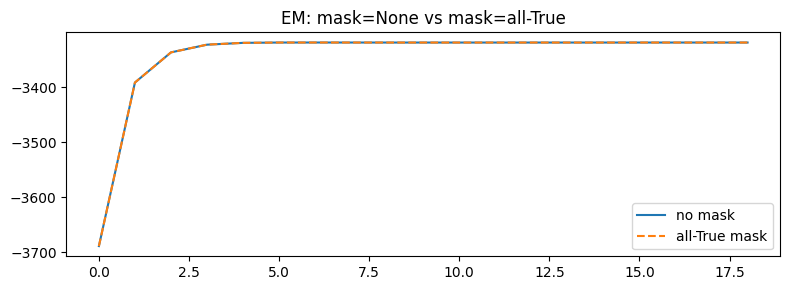

In [4]:
num_iters = 20

# FA model with full settings: ARD, PX, BMR

# --- EM ---
fa_model = BFA(K, D)
key, subkey = jr.split(key)
init_params_em, props_em = fa_model.initialize(subkey, variational_bayes=False)

key, subkey = jr.split(key)
params_no_mask, elbos_no_mask = fa_model.fit_em(
    init_params_em, props_em, Y_fa, subkey, num_iters=num_iters
)

fa_model = BFA(K, D)
params_all_mask, elbos_all_mask = fa_model.fit_em(
    init_params_em, props_em, Y_fa, subkey, mask=jnp.ones((N, D), dtype=bool), num_iters=num_iters
)

print("EM regression test:")
print(f"  ELBO diff (last): {abs(elbos_no_mask[-1] - elbos_all_mask[-1]):.6f}")
print(f"  Max ELBO diff:    {jnp.max(jnp.abs(elbos_no_mask - elbos_all_mask)):.6f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(elbos_no_mask, label="no mask")
ax.plot(elbos_all_mask, '--', label="all-True mask")
ax.set_title("EM: mask=None vs mask=all-True")
ax.legend()
plt.tight_layout()

VBEM regression test:
  ELBO diff (last): 0.000488
  Max ELBO diff:    0.239746


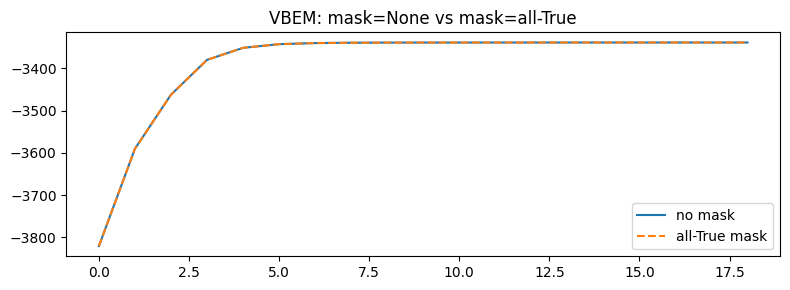

In [5]:
# --- VBEM ---
key, subkey = jr.split(key)
init_params_vb, props_vb = fa_model.initialize(subkey, variational_bayes=True)


fa_model = BFA(K, D)
key, subkey = jr.split(key)
params_vb_no_mask, elbos_vb_no_mask = fa_model.fit_vbem(
    init_params_vb, props_vb, Y_fa, subkey, num_iters=num_iters
)

fa_model = BFA(K, D)
params_vb_all_mask, elbos_vb_all_mask = fa_model.fit_vbem(
    init_params_vb, props_vb, Y_fa, subkey, mask=jnp.ones((N, D), dtype=bool), num_iters=num_iters
)

print("VBEM regression test:")
print(f"  ELBO diff (last): {abs(elbos_vb_no_mask[-1] - elbos_vb_all_mask[-1]):.6f}")
print(f"  Max ELBO diff:    {jnp.max(jnp.abs(elbos_vb_no_mask - elbos_vb_all_mask)):.6f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(elbos_vb_no_mask, label="no mask")
ax.plot(elbos_vb_all_mask, '--', label="all-True mask")
ax.set_title("VBEM: mask=None vs mask=all-True")
ax.legend()
plt.tight_layout()

Gibbs regression test:
  ELBO diff (last): 0.006836


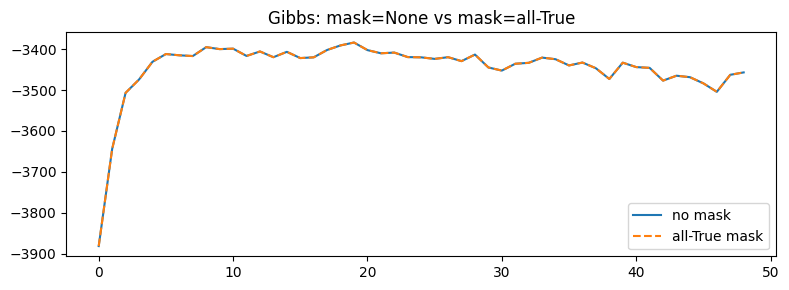

In [6]:
# --- Gibbs ---
key, subkey = jr.split(key)
init_params_gibbs, props_gibbs = fa_model.initialize(subkey)

key, subkey = jr.split(key)
fa_model = BFA(K, D)
params_gibbs_no_mask, elbos_gibbs_no_mask = fa_model.fit_blocked_gibbs(
    subkey, init_params_gibbs, props_gibbs, sample_size=50, emissions=Y_fa
)


fa_model = BFA(K, D)
params_gibbs_all_mask, elbos_gibbs_all_mask = fa_model.fit_blocked_gibbs(
    subkey, init_params_gibbs, props_gibbs, sample_size=50, emissions=Y_fa,
    mask=jnp.ones((N, D), dtype=bool)
)

print("Gibbs regression test:")
print(f"  ELBO diff (last): {abs(elbos_gibbs_no_mask[-1] - elbos_gibbs_all_mask[-1]):.6f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(elbos_gibbs_no_mask[1:], label="no mask")
ax.plot(elbos_gibbs_all_mask[1:], '--', label="all-True mask")
ax.set_title("Gibbs: mask=None vs mask=all-True")
ax.legend()
plt.tight_layout()

## 1.2 FA: Masked training vs subset training

For FA (static mode), masking certain dimensions for certain samples should give similar results to training only on the observed entries. We compare by masking a subset of dimensions and training with the mask vs training on only the fully-observed subset.

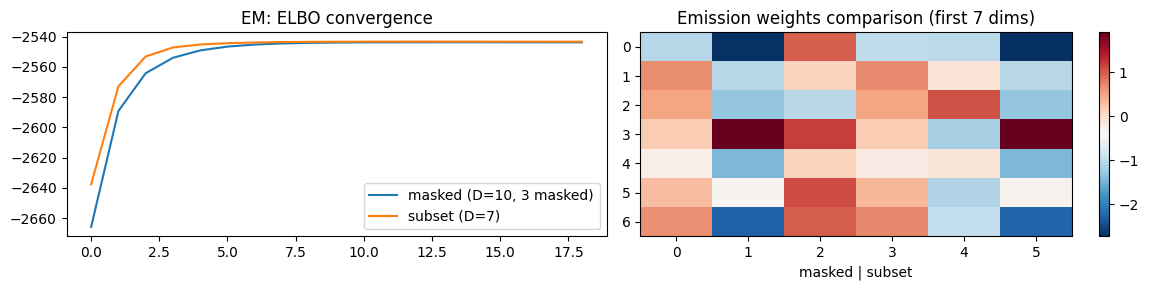

In [7]:
# Strategy: mask the last 3 dimensions for the first 250 samples
# Then the "subset" training uses only the first 7 dims for those samples
# and all 10 dims for the remaining 250

num_iters = 20


# Let's mask dims 7,8,9 for all samples → equivalent to training on dims 0-6 only
mask_partial = jnp.ones((N, D), dtype=bool)
mask_partial = mask_partial.at[:, 7:].set(False)

# Subset: only use first 7 dimensions
Y_subset = Y_fa[:, :7]
Y_masked = Y_fa * mask_partial

fa_model_full = BFA(K, D, use_ard=True, use_px=True)
fa_model_sub = BFA(K, 7, use_ard=True, use_px=True)

# --- EM with mask ---
key, subkey = jr.split(key)
init_full, props_full = fa_model_full.initialize(subkey, variational_bayes=False)

key, subkey = jr.split(key)
params_masked, elbos_masked = fa_model_full.fit_em(
    init_full, props_full, Y_masked, subkey, mask=mask_partial, num_iters=num_iters
)

# --- EM with subset ---
key, subkey = jr.split(key)
init_sub, props_sub = fa_model_sub.initialize(subkey, variational_bayes=False)

key, subkey = jr.split(key)
params_subset, elbos_subset = fa_model_sub.fit_em(
    init_sub, props_sub, Y_subset, subkey, num_iters=num_iters
)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(elbos_masked, label="masked (D=10, 3 masked)")
axes[0].plot(elbos_subset, label="subset (D=7)")
axes[0].set_title("EM: ELBO convergence")
axes[0].legend()

# Compare learned emission weights for the observed dims
H_masked = params_masked.emissions.weights[:7, :K]
H_subset = params_subset.emissions.weights[:, :K]
axes[1].set_title("Emission weights comparison (first 7 dims)")
im = axes[1].imshow(jnp.concatenate([H_masked, H_subset], axis=1), aspect='auto', cmap='RdBu_r')
axes[1].set_xlabel("masked | subset")
plt.colorbar(im, ax=axes[1])
plt.tight_layout()

## 1.3 FA with random masking (30% missing)

Train FA with all three methods using random per-sample masking.

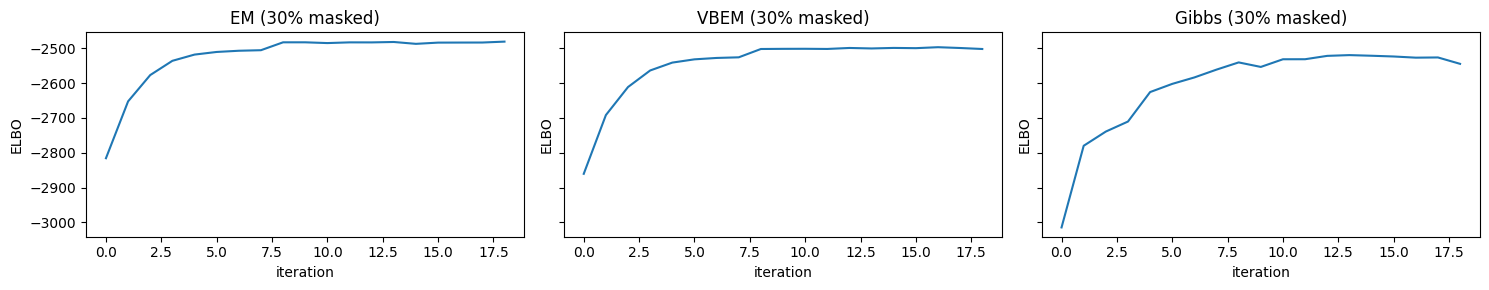

In [8]:
use_bmr = True

fa_model = BFA(K, D, use_bmr=use_bmr)

# EM
key, subkey = jr.split(key)
init_em, props_em = fa_model.initialize(subkey, variational_bayes=False)
key, subkey = jr.split(key)
params_em_masked, elbos_em_masked = fa_model.fit_em(
    init_em, props_em, Y_fa, subkey, mask=mask_fa, num_iters=num_iters, bmr_start_iter=8
)

fa_model = BFA(K, D, use_bmr=use_bmr)

# VBEM
key, subkey = jr.split(key)
init_vb, props_vb = fa_model.initialize(subkey, variational_bayes=True)
key, subkey = jr.split(key)
params_vb_masked, elbos_vb_masked = fa_model.fit_vbem(
    init_vb, props_vb, Y_fa, subkey, mask=mask_fa, num_iters=num_iters, bmr_start_iter=8
)

fa_model = BFA(K, D, use_bmr=use_bmr)

# Gibbs
key, subkey = jr.split(key)
init_gibbs, props_gibbs = fa_model.initialize(subkey)
key, subkey = jr.split(key)
params_gibbs_masked, elbos_gibbs_masked = fa_model.fit_blocked_gibbs(
    subkey, init_gibbs, props_gibbs, sample_size=20, emissions=Y_fa, mask=mask_fa, burn_in=1
)

fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharey=True)
axes[0].plot(elbos_em_masked)
axes[0].set_title("EM (30% masked)")
axes[1].plot(elbos_vb_masked)
axes[1].set_title("VBEM (30% masked)")
axes[2].plot(elbos_gibbs_masked)
axes[2].set_title("Gibbs (30% masked)")
for ax in axes:
    ax.set_xlabel("iteration")
    ax.set_ylabel("ELBO")
plt.tight_layout()

# Part 2: Dynamic Factor Analysis (DFA)

Generate synthetic DFA time series data.

DFA data shape: (200, 10)


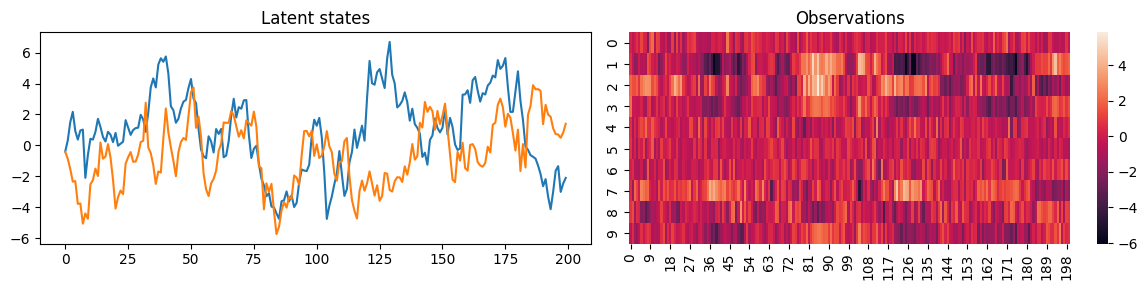

In [9]:
key = jr.PRNGKey(42)
K_dfa = 2    # latent factors
D_dfa = 10   # observation dimensions
T = 200      # timesteps

# True DFA parameters
A_true = jnp.array([[0.9, 0.0], [0.0, 0.85]])
Q_true = jnp.eye(K_dfa)

key, subkey, subkey2 = jr.split(key, 3)
C_true_dfa = jr.normal(subkey, (D_dfa, K_dfa)) * jr.bernoulli(subkey2, p=0.3, shape=(D_dfa, K_dfa))

key, subkey = jr.split(key)
R_true_dfa = jr.uniform(subkey, (D_dfa,), minval=0.3, maxval=1.0)

# Generate latent states and observations
z = jnp.zeros((T, K_dfa))
Y_dfa = jnp.zeros((T, D_dfa))

key, subkey1, subkey2 = jr.split(key, 3)
z_curr = jr.normal(subkey1, (K_dfa,))
z = z.at[0].set(z_curr)
Y_dfa = Y_dfa.at[0].set(C_true_dfa @ z_curr + jr.normal(subkey2, (D_dfa,)) * jnp.sqrt(R_true_dfa))

for t in range(1, T):
    key, subkey1, subkey2 = jr.split(key, 3)
    z_curr = A_true @ z_curr + jr.normal(subkey1, (K_dfa,))
    z = z.at[t].set(z_curr)
    Y_dfa = Y_dfa.at[t].set(C_true_dfa @ z_curr + jr.normal(subkey2, (D_dfa,)) * jnp.sqrt(R_true_dfa))

print(f"DFA data shape: {Y_dfa.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(z)
axes[0].set_title("Latent states")
sns.heatmap(Y_dfa.T, ax=axes[1], cbar=True)
axes[1].set_title("Observations")
plt.tight_layout()

## 2.1 DFA regression test: mask=None vs mask=all-True

EM: max ELBO diff = 0.000732
VBEM: max ELBO diff = 19.935547


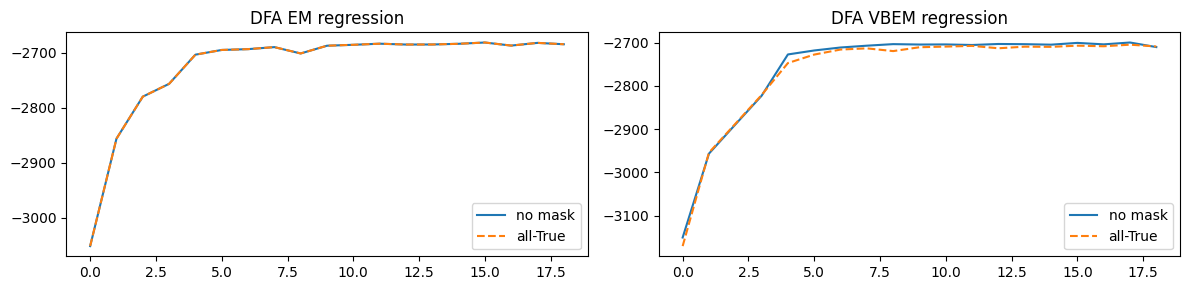

In [10]:
num_iters_dfa = 20

dfa_model = BDFA(K_dfa, D_dfa, use_bmr=True)
all_true_mask = jnp.ones((T, D_dfa), dtype=bool)

# --- EM ---
key, subkey = jr.split(key)
init_em, props_em = dfa_model.initialize(subkey, variational_bayes=False)

key, subkey = jr.split(key)
p_em_none, e_em_none = dfa_model.fit_em(init_em, props_em, Y_dfa, subkey, num_iters=num_iters_dfa)

dfa_model = BDFA(K_dfa, D_dfa, use_bmr=True)
p_em_all, e_em_all = dfa_model.fit_em(init_em, props_em, Y_dfa, subkey, mask=all_true_mask, num_iters=num_iters_dfa)

print(f"EM: max ELBO diff = {jnp.max(jnp.abs(e_em_none - e_em_all)):.6f}")

# --- VBEM ---
key, subkey = jr.split(key)
init_vb, props_vb = dfa_model.initialize(subkey, variational_bayes=True)

dfa_model = BDFA(K_dfa, D_dfa, use_bmr=True)
key, subkey = jr.split(key)
p_vb_none, e_vb_none = dfa_model.fit_vbem(init_vb, props_vb, Y_dfa, subkey, num_iters=num_iters_dfa)

dfa_model = BDFA(K_dfa, D_dfa, use_bmr=True)
p_vb_all, e_vb_all = dfa_model.fit_vbem(init_vb, props_vb, Y_dfa, subkey, mask=all_true_mask, num_iters=num_iters_dfa)

print(f"VBEM: max ELBO diff = {jnp.max(jnp.abs(e_vb_none - e_vb_all)):.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(e_em_none, label="no mask")
axes[0].plot(e_em_all, '--', label="all-True")
axes[0].set_title("DFA EM regression")
axes[0].legend()

axes[1].plot(e_vb_none, label="no mask")
axes[1].plot(e_vb_all, '--', label="all-True")
axes[1].set_title("DFA VBEM regression")
axes[1].legend()
plt.tight_layout()

## 2.2 DFA with random masking (70% missing)

Train DFA with all three methods using random time-varying masking.

DFA mask shape: (200, 10), fraction observed: 0.30


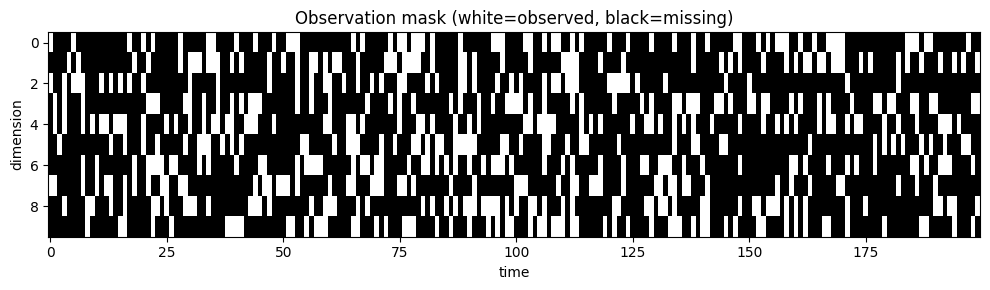

In [11]:
# Random mask: 30% of entries missing
key, subkey = jr.split(key)
mask_dfa = jr.bernoulli(subkey, p=0.3, shape=(T, D_dfa))
print(f"DFA mask shape: {mask_dfa.shape}, fraction observed: {mask_dfa.mean():.2f}")

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.imshow(mask_dfa.T, aspect='auto', cmap='gray', interpolation='none')
ax.set_xlabel("time")
ax.set_ylabel("dimension")
ax.set_title("Observation mask (white=observed, black=missing)")
plt.tight_layout()

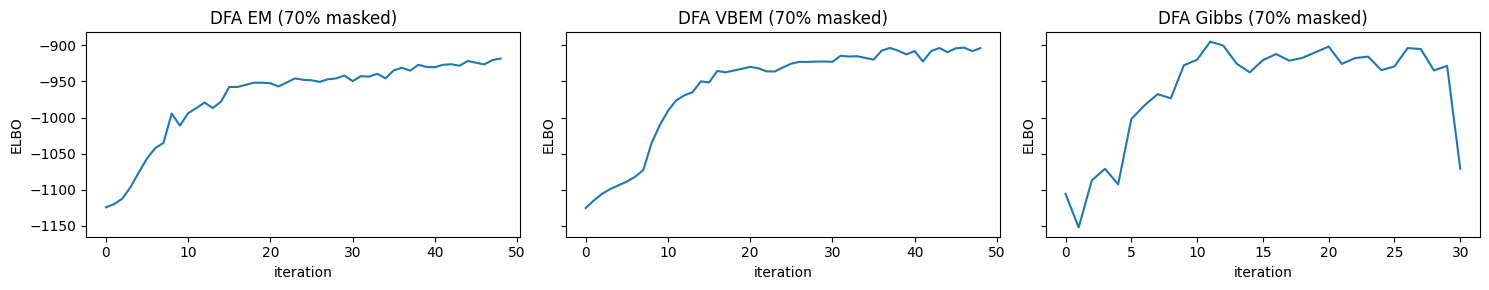

In [12]:
num_iters_dfa = 50

dfa_model = BDFA(K_dfa, D_dfa, use_bmr=True)

# EM with mask
key, subkey = jr.split(key)
init_em, props_em = dfa_model.initialize(subkey, variational_bayes=False)
key, subkey = jr.split(key)
params_dfa_em, elbos_dfa_em = dfa_model.fit_em(
    init_em, props_em, Y_dfa, subkey, mask=mask_dfa, num_iters=num_iters_dfa, bmr_start_iter=8
)

dfa_model = BDFA(K_dfa, D_dfa, use_bmr=True)

# VBEM with mask
key, subkey = jr.split(key)
init_vb, props_vb = dfa_model.initialize(subkey, variational_bayes=True)
key, subkey = jr.split(key)
params_dfa_vb, elbos_dfa_vb = dfa_model.fit_vbem(
    init_vb, props_vb, Y_dfa, subkey, mask=mask_dfa, num_iters=num_iters_dfa, bmr_start_iter=8
)

dfa_model = BDFA(K_dfa, D_dfa, use_bmr=True)

# Gibbs with mask
key, subkey = jr.split(key)
init_gibbs, props_gibbs = dfa_model.initialize(subkey)
key, subkey = jr.split(key)
params_dfa_gibbs, elbos_dfa_gibbs = dfa_model.fit_blocked_gibbs(
    subkey, init_gibbs, props_gibbs, sample_size=num_iters_dfa + 1, emissions=Y_dfa, mask=mask_dfa, burn_in=1, bmr_start_iter=9
)

fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharey=True)
axes[0].plot(elbos_dfa_em)
axes[0].set_title("DFA EM (70% masked)")
axes[1].plot(elbos_dfa_vb)
axes[1].set_title("DFA VBEM (70% masked)")
axes[2].plot(elbos_dfa_gibbs)
axes[2].set_title("DFA Gibbs (70% masked)")
for ax in axes:
    ax.set_xlabel("iteration")
    ax.set_ylabel("ELBO")
plt.tight_layout()

## 2.3 DFA with partial time-varying masking

First half of time: only dims 0-4 observed. Second half: only dims 5-9 observed.
This tests that the model can maintain temporal continuity through the latent states even when observation dimensions change completely over time.

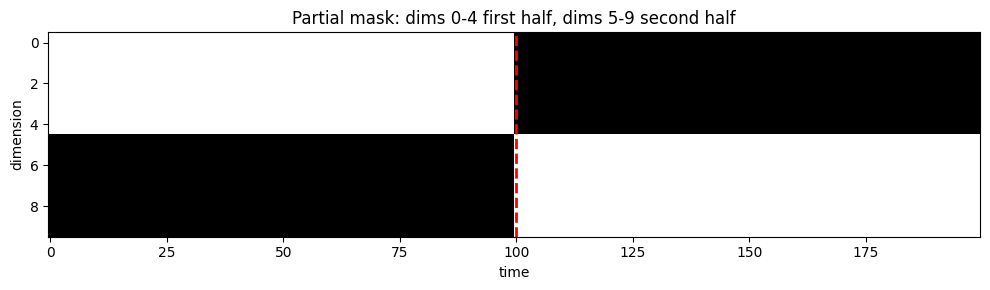

In [13]:
# Partial time-varying mask: first half dims 0-4, second half dims 5-9
mask_partial_tv = jnp.zeros((T, D_dfa), dtype=bool)
mask_partial_tv = mask_partial_tv.at[:T//2, :5].set(True)   # first half: dims 0-4
mask_partial_tv = mask_partial_tv.at[T//2:, 5:].set(True)   # second half: dims 5-9

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.imshow(mask_partial_tv.T, aspect='auto', cmap='gray', interpolation='none')
ax.set_xlabel("time")
ax.set_ylabel("dimension")
ax.set_title("Partial mask: dims 0-4 first half, dims 5-9 second half")
ax.axvline(T//2, color='red', linestyle='--', lw=2)
plt.tight_layout()

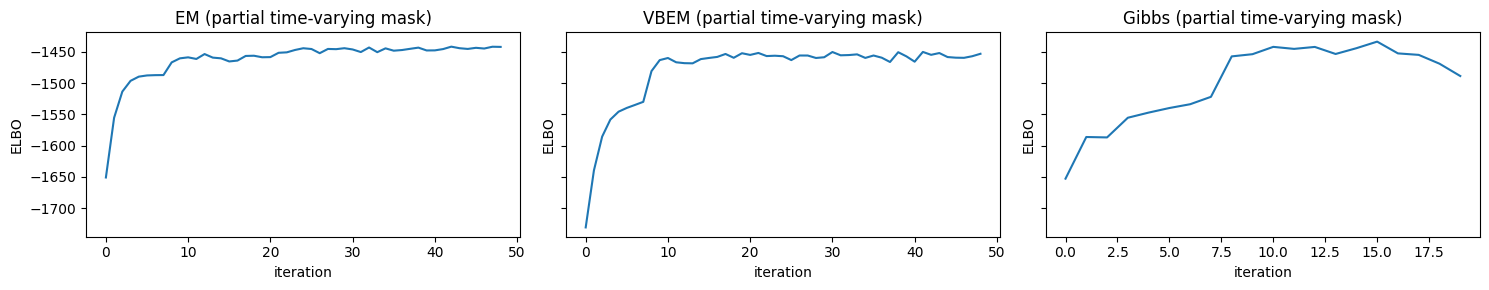

In [14]:
dfa_model = BDFA(K_dfa, D_dfa, use_bmr=True)

# EM
key, subkey = jr.split(key)
init_em, props_em = dfa_model.initialize(subkey, variational_bayes=False)
key, subkey = jr.split(key)
params_ptv_em, elbos_ptv_em = dfa_model.fit_em(
    init_em, props_em, Y_dfa, subkey, mask=mask_partial_tv, num_iters=num_iters_dfa, bmr_start_iter=8
)

dfa_model = BDFA(K_dfa, D_dfa, use_bmr=True)

# VBEM
key, subkey = jr.split(key)
init_vb, props_vb = dfa_model.initialize(subkey, variational_bayes=True)
key, subkey = jr.split(key)
params_ptv_vb, elbos_ptv_vb = dfa_model.fit_vbem(
    init_vb, props_vb, Y_dfa, subkey, mask=mask_partial_tv, num_iters=num_iters_dfa, bmr_start_iter=8
)

dfa_model = BDFA(K_dfa, D_dfa, use_bmr=True)

# Gibbs
key, subkey = jr.split(key)
init_gibbs, props_gibbs = dfa_model.initialize(subkey)
key, subkey = jr.split(key)
params_ptv_gibbs, elbos_ptv_gibbs = dfa_model.fit_blocked_gibbs(
    subkey, init_gibbs, props_gibbs, sample_size=num_iters + 1, emissions=Y_dfa, mask=mask_partial_tv, burn_in=1, bmr_start_iter=8
)

fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharey=True)
axes[0].plot(elbos_ptv_em)
axes[0].set_title("EM (partial time-varying mask)")
axes[1].plot(elbos_ptv_vb)
axes[1].set_title("VBEM (partial time-varying mask)")
axes[2].plot(elbos_ptv_gibbs)
axes[2].set_title("Gibbs (partial time-varying mask)")
for ax in axes:
    ax.set_xlabel("iteration")
    ax.set_ylabel("ELBO")
plt.tight_layout()

## 2.4 Compare masked vs full DFA training

Show that random masking degrades gracefully compared to full data.

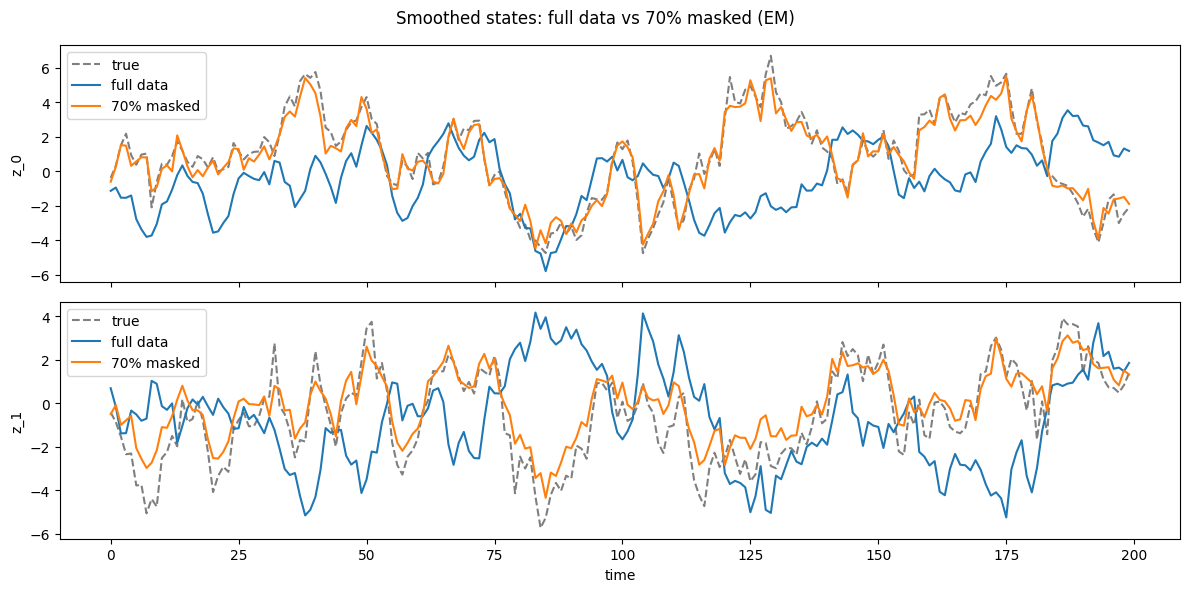

In [15]:
from dynamax.linear_gaussian_ssm import lgssm_smoother

dfa_model = BDFA(K_dfa, D_dfa, use_bmr=True)

# Train full model without mask for comparison
key, subkey = jr.split(key)
init_em_full, props_em_full = dfa_model.initialize(subkey, variational_bayes=True)
key, subkey = jr.split(key)
params_full, elbos_full = dfa_model.fit_vbem(
    init_em_full, props_em_full, Y_dfa, subkey, num_iters=num_iters_dfa, bmr_start_iter=8
)

fig, axes = plt.subplots(K_dfa, 1, figsize=(12, 3 * K_dfa), sharex=True)
post_full = lgssm_smoother(params_full, Y_dfa)
post_masked_em = lgssm_smoother(params_dfa_vb, Y_dfa)

for i in range(K_dfa):
    axes[i].plot(z[:, i], '--k', alpha=0.5, label='true')
    axes[i].plot(post_full.smoothed_means[:, i], label='full data')
    axes[i].plot(post_masked_em.smoothed_means[:, i], label='70% masked')
    axes[i].set_ylabel(f'z_{i}')
    axes[i].legend()
axes[-1].set_xlabel('time')
fig.suptitle("Smoothed states: full data vs 70% masked (EM)")
plt.tight_layout()